# 01. Modelo base: Regresión Logística


Este notebook entrena una regresión logística con los hiperparámetros por defecto de scikit-learn (sin búsqueda todavía), y reporta **score (accuracy)** y **error (log-loss)** junto con AUC-ROC, coeficientes, matriz de confusión y curva ROC. Como ya adelantaba el EDA (desbalance de clases 77.9% / 22.1%), el objetivo es mostrar que el accuracy por sí solo esconde un margen de mejora real, el mismo margen que el pipeline completo (balanceo, optimización de hiperparámetros, comparación de 7 modelos) busca cerrar.

## 1. Preparación de los datos

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, log_loss, confusion_matrix,
    classification_report, roc_auc_score, roc_curve,
)

from src import config
from src.data_loader import load_processed_dataset
from src.preprocessing import build_column_transformer

np.random.seed(config.RANDOM_STATE)
sns.set_style("white")
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

COLOR_GOOD = "#0ca30c"       # no default
COLOR_CRITICAL = "#d03b3b"   # default
COLOR_SEQ_DARK = "#184f95"


### 1.1 Carga del dataset final



In [2]:
df = load_processed_dataset()

print(f"Dimensiones: {df.shape}")
df[config.TARGET_COLUMN].value_counts(normalize=True).rename("proporción")

Dimensiones: (29965, 21)


default_payment_next_month
0    0.778742
1    0.221258
Name: proporción, dtype: float64

## 2. División train/test, encoding y escalado

Partición estratificada 80/20 con `config.RANDOM_STATE`. El preprocesamiento y el modelo van en un Pipeline para evitar fuga de información y reutilizar `build_column_transformer` de `src/preprocessing.py.`

In [3]:
X, y = df.drop(columns=[config.TARGET_COLUMN]), df[config.TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=config.RANDOM_STATE
)

print(f"Entrenamiento: {X_train.shape[0]:,} filas | Prueba: {X_test.shape[0]:,} filas")
print(f"Proporción de default: train {y_train.mean():.4f} | test {y_test.mean():.4f}")

Entrenamiento: 23,972 filas | Prueba: 5,993 filas
Proporción de default: train 0.2213 | test 0.2213


## 3. Ajuste del modelo

Regresión logística con los hiperparámetros por defecto de scikit-learn (`C = 1`, penalización L2), sin búsqueda de hiperparámetro todavía: ese es justamente el trabajo del pipeline completo (`03_pipeline_dev.ipynb` en adelante), que compara 7 modelos base × 4 técnicas de balanceo × 4 métodos de optimización con validación cruzada anidada (ver README). Este notebook es el punto de partida con el que comparar esa mejora.

In [4]:
modelo_base = Pipeline([
    ("preprocessing", build_column_transformer(apply_scaling=True)),
    ("logreg", LogisticRegression(max_iter=2000, random_state=config.RANDOM_STATE)),
])
modelo_base.fit(X_train, y_train)

print(f"Modelo ajustado: Regresión Logística (C = {modelo_base.named_steps['logreg'].C})")

Modelo ajustado: Regresión Logística (C = 1.0)


## 4. Evaluación: score, error y AUC-ROC

Además del *score* (accuracy) y el *error* (log-loss) pedidos, se reporta AUC-ROC: con el desbalance de clases documentado en el EDA (77.9% / 22.1%), el accuracy por sí solo puede esconder un margen de mejora real: un modelo que prediga siempre "no default" ya alcanzaría un accuracy parecido al de referencia.

In [5]:
y_pred = modelo_base.predict(X_test)
y_proba = modelo_base.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
logloss = log_loss(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba[:, 1])
baseline_ingenuo = (y_test == 0).mean()

print(f"Referencia (predecir siempre 'no default'): accuracy = {baseline_ingenuo:.4f}")
resultados_modelo = pd.DataFrame([{
    "modelo": "Regresión Logística (base)",
    "accuracy (score)": round(accuracy, 4),
    "log_loss (error)": round(logloss, 4),
    "roc_auc": round(auc, 4),
}])
resultados_modelo

Referencia (predecir siempre 'no default'): accuracy = 0.7787


,modelo,accuracy (score),log_loss (error),roc_auc
0,Regresión Logística (base),0.8056,0.4552,0.7407


El modelo obtiene un **accuracy de aproximadamente 80.6%**, un **log-loss de aproximadamente 0.455** y un **AUC-ROC de aproximadamente 0.741** sobre el conjunto de prueba. El accuracy supera al baseline ingenuo (77.9%) por 2.7 puntos porcentuales, un margen modesto que por sí solo no dice nada sobre qué tan bien identifica el modelo a los clientes que sí caen en default: eso lo revela recién la matriz de confusión de la sección 6. El AUC-ROC (0.741), bastante por encima del 0.5 de un clasificador aleatorio, confirma que hay señal aprovechable en los datos, coherente con el ranking SHAP del EDA, donde `PAY_0` y las demás variables de atraso dominaban la importancia; pero un AUC de 0.74 tampoco es un techo: es el margen que el pipeline completo, con balanceo de clases y optimización de hiperparámetros, va a intentar cerrar.

Frente a la versión anterior de este notebook, que usaba el dataset sin transformaciones logarítmicas (accuracy 81.3%, log-loss 0.466, AUC-ROC 0.719), el AUC-ROC y el log-loss mejoran mientras que el accuracy baja ligeramente: el modelo ordena mejor a los clientes por riesgo, pero con el umbral por defecto de 0.5 acierta algo menos en la clase mayoritaria. Probablemente se deba a que, con el log, `LIMIT_BAL` y los montos pagados (de colas muy largas) dejan de estar dominados por unos pocos valores extremos y aportan más a un modelo lineal.

## 5. Coeficientes del modelo

In [6]:
preproc = modelo_base.named_steps["preprocessing"]
feature_names = preproc.get_feature_names_out()

coeficientes = (
    pd.Series(modelo_base.named_steps["logreg"].coef_[0], index=feature_names, name="coeficiente")
    .sort_values(key=abs, ascending=False)
    .round(4)
)
coeficientes

categorical__EDUCATION_4             -0.9575
remainder__PAY_0                      0.5242
categorical__MARRIAGE_2              -0.4057
categorical__MARRIAGE_3              -0.3819
categorical__MARRIAGE_1              -0.2331
remainder__BILL_AMT_MEAN_6M_LOG      -0.2208
remainder__PAY_2                      0.1701
remainder__BILL_AMT_TREND_6M_LOG     -0.1203
remainder__PAY_3                      0.1198
remainder__PAY_AMT3_LOG              -0.1161
remainder__LIMIT_BAL_LOG             -0.1135
remainder__PAY_AMT1_LOG              -0.1079
remainder__PAY_5                      0.0863
remainder__PAY_AMT2_LOG              -0.0848
categorical__SEX_2                   -0.0815
remainder__PAY_6                      0.0807
remainder__N_CREDIT_BALANCE_MONTHS   -0.0774
remainder__PAY_AMT4_LOG              -0.0756
categorical__EDUCATION_3             -0.0721
remainder__PAY_AMT5_LOG              -0.0427
remainder__PAY_AMT6_LOG              -0.0403
remainder__PAY_4                      0.0387
remainder_

Los signos son, en general, coherentes con el análisis exploratorio. Las numéricas están estandarizadas, así que las magnitudes de sus coeficientes son comparables entre sí. `PAY_0` (estado de pago más reciente) tiene, de lejos, el coeficiente positivo más grande entre las variables numéricas (0.52), el mismo protagonismo que tenía en el ranking SHAP del EDA; `PAY_2` y `PAY_3` le siguen con efectos menores. `LIMIT_BAL_LOG` y los montos pagados (`PAY_AMT1_LOG` a `PAY_AMT6_LOG`) son negativos (mayor límite de crédito o mayor pago histórico → menor riesgo), y `SEX_2` (mujer) es negativo, consistente con la menor tasa de default observada en el EDA (20.8% vs. 24.2% en hombres). Dentro de `EDUCATION`, la categoría "Otros" (`EDUCATION_4`) tiene el coeficiente más negativo de todo el modelo, coherente con la tasa de default más baja que encontró el EDA en ese grupo (7.1%, aunque solo el 1.6% de la muestra).

El bloque de facturación, que antes tenía seis coeficientes inestables por colinealidad, queda representado por tres variables derivadas con un coeficiente cada una: `BILL_AMT_MEAN_6M_LOG` (-0.22), `BILL_AMT_TREND_6M_LOG` (-0.12) y `N_CREDIT_BALANCE_MONTHS` (-0.08). Con la multicolinealidad resuelta (VIF máximo de 5.8 en todo el dataset, según la Parte 5 del EDA), cada coeficiente se puede leer como el efecto de esa variable manteniendo las demás fijas. Los tres son negativos: una vez conocidos los atrasos y los pagos, una facturación media mayor o más meses con saldo a favor se asocian a menor probabilidad de default. No debe leerse como que facturar más protege por sí mismo, sino como un ajuste condicional a las demás variables.

## 6. Matriz de confusión, reporte de clasificación y curva ROC

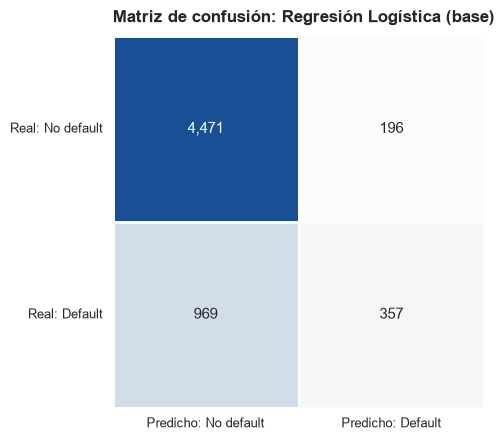

Reporte de clasificación: Regresión Logística (base)

                precision    recall  f1-score   support

No default (0)       0.82      0.96      0.88      4667
   Default (1)       0.65      0.27      0.38      1326

      accuracy                           0.81      5993
     macro avg       0.73      0.61      0.63      5993
  weighted avg       0.78      0.81      0.77      5993



In [7]:
matriz = confusion_matrix(y_test, y_pred)
cmap_confusion = sns.blend_palette(["#fcfcfb", COLOR_SEQ_DARK], as_cmap=True)

fig, ax = plt.subplots(figsize=(5, 4.5))
sns.heatmap(matriz, annot=True, fmt=",d", cmap=cmap_confusion, cbar=False, square=True,
            linewidths=1, linecolor="#fcfcfb", annot_kws={"fontsize": 11}, ax=ax)
ax.set_xticklabels(["Predicho: No default", "Predicho: Default"], fontsize=9)
ax.set_yticklabels(["Real: No default", "Real: Default"], fontsize=9, rotation=0)
ax.set_title("Matriz de confusión: Regresión Logística (base)", fontsize=12, fontweight="bold", loc="left", pad=10)
plt.tight_layout()
plt.show()

print("Reporte de clasificación: Regresión Logística (base)\n")
print(classification_report(y_test, y_pred, target_names=["No default (0)", "Default (1)"]))

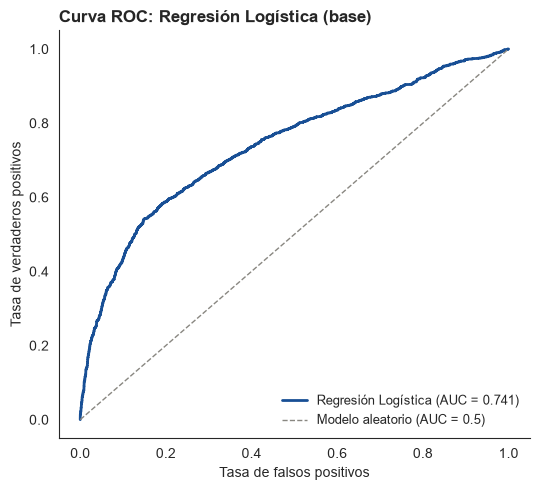

In [8]:
fpr, tpr, _ = roc_curve(y_test, y_proba[:, 1])

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=COLOR_SEQ_DARK, linewidth=2, label=f"Regresión Logística (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], color="#898781", linestyle="--", linewidth=1, label="Modelo aleatorio (AUC = 0.5)")
ax.set_title("Curva ROC: Regresión Logística (base)", fontsize=12, fontweight="bold", loc="left")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

La matriz de confusión cuantifica el margen de mejora que el accuracy y el AUC-ROC dejaban entrever: de los 1,326 clientes con default en el conjunto de prueba, el modelo identifica correctamente solo **357 (recall = 26.9%)** y pasa por alto **969**; de los 4,667 clientes sin default, identifica correctamente 4,471 (recall = 95.8%). Cuando el modelo sí predice default, acierta el 64.6% de las veces (precisión de la clase 1), pero eso ocurre con poca frecuencia dado el recall bajo: el F1 de la clase 1 queda en 0.38, frente a 0.88 de la clase 0.

Esto es consistente con no aplicar ponderación de clases (`class_weight`) ni ajustar el umbral de decisión: por defecto, `predict()` usa un umbral de 0.5, que en un dataset con 77.9% de la clase mayoritaria favorece sistemáticamente esa clase. El AUC-ROC (0.741) evalúa el modelo a través de todos los umbrales posibles y muestra que las probabilidades predichas sí ordenan razonablemente bien a los clientes por riesgo. La brecha entre un AUC decente y un recall bajo no es falta de señal, es el efecto del umbral por defecto sobre un problema desbalanceado.

## 7. Síntesis

- El modelo base de Regresión Logística obtiene un **accuracy de aproximadamente 80.6%**, un **log-loss de aproximadamente 0.455** y un **AUC-ROC de aproximadamente 0.741** sobre el conjunto de prueba, superando al baseline ingenuo (77.9%) por 2.7 puntos porcentuales.
- Ese accuracy, sin embargo, esconde un margen de mejora real: el modelo solo detecta al **26.9%** de los clientes que efectivamente caen en default (recall de la clase 1), aunque el AUC (0.741) confirma que sí existe señal suficiente para ordenar el riesgo. La brecha es el umbral de decisión por defecto (0.5) en un problema desbalanceado (77.9% / 22.1%), no ausencia de información.
- Los coeficientes son coherentes con el EDA para la mayoría de las variables (`PAY_0` como predictor dominante, `LIMIT_BAL_LOG` y los montos pagados con signo negativo, `SEX`/`EDUCATION` reflejando las diferencias de tasa de default ya documentadas). El preprocesamiento del EDA (Parte 5) deja el bloque de facturación resumido en `BILL_AMT_MEAN_6M_LOG`, `BILL_AMT_TREND_6M_LOG` y `N_CREDIT_BALANCE_MONTHS`, sin la multicolinealidad severa (VIF hasta ~25) que producía coeficientes inestables con signo opuesto entre `BILL_AMT1` y `BILL_AMT2`, y las transformaciones logarítmicas mejoran el AUC-ROC y el log-loss respecto a la versión sin transformar.
- **Próximos pasos** (ya implementados en el pipeline completo, `03_pipeline_dev.ipynb` en adelante, pendientes de volver a correr con este dataset preprocesado): ponderación de clases o remuestreo (`class_weight`, SMOTE, etc.), ajuste de umbral de decisión, optimización de hiperparámetros (Grid/Random/Bayesiana/Genética) y comparación contra otros 6 modelos base (árboles, ensambles, SVM, KNN, Naive Bayes) con validación cruzada anidada: precisamente el margen que este modelo base deja claramente documentado. Todos los modelos reciben el mismo dataset de `data/processed/dataset_final.csv`.